## Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from DNNLabExam.Q1 import x_train, y_train, y_test

In [2]:
df = pd.read_csv('letterdata.csv')

In [3]:
df

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19998,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


In [4]:
x = df.drop('letter', axis = 1)
y = df['letter']

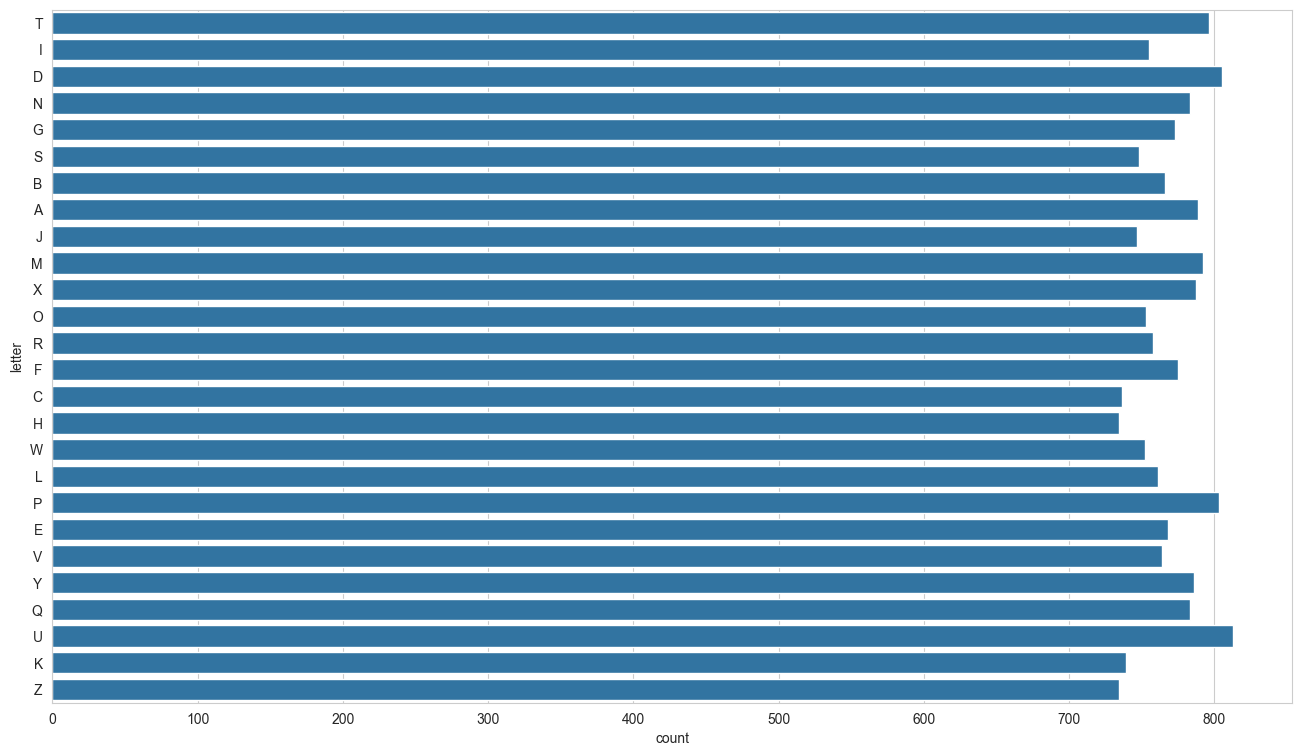

In [7]:
plt.figure(figsize=(16,9))
sns.countplot(y=y);

In [8]:
y.value_counts()

letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64

### Cross Validation

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 0, stratify=y)

In [11]:
x_train.shape

(15000, 16)

In [12]:
x_test.shape

(5000, 16)

### Build the model

In [13]:
from sklearn.svm import SVC

In [15]:
svm_lr = SVC(kernel = 'linear')
svm_lr.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
from sklearn.metrics import accuracy_score

In [24]:
y_pred_lr = svm_lr.predict(x_test)

In [25]:
# linear
accuracy_score(y_test, y_pred_lr)

0.847

In [26]:
# rbf
svm_rbf = SVC()
svm_rbf.fit(x_train, y_train)
y_pred_rbf = svm_rbf.predict(x_test)
accuracy_score(y_test, y_pred_rbf)

0.928

In [27]:
# Poly
svm_poly = SVC(kernel = 'poly')
svm_poly.fit(x_train, y_train)
y_pred_poly = svm_poly.predict(x_test)
accuracy_score(y_test, y_pred_poly)

0.9456

In [28]:
# Sigmoid
svm_sigmoid = SVC(kernel = 'sigmoid')
svm_sigmoid.fit(x_train, y_train)
y_pred_sigmoid = svm_sigmoid.predict(x_test)
accuracy_score(y_test, y_pred_sigmoid)

0.0296